In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


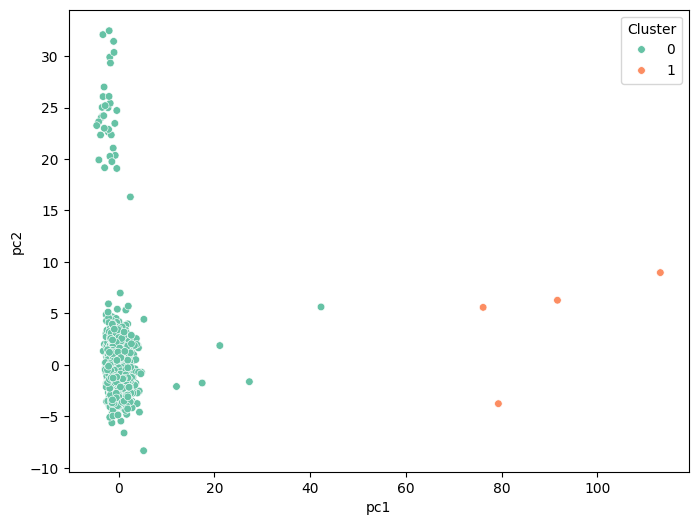

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

---
---

In [27]:
def local_surrogate_lattice_cube_linear(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=500,
    delta=0.1,                 # 標準化空間格點步長
    k=None,                    # 若給定則固定半徑層數；否則依 n_samples 自動估
    max_full_grid=200_000,     # 允許完整展開的最大點數
    random_state=None,
):
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0, dtype=float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]
    if p < 1:
        raise ValueError("x0 必須至少有 1 個特徵")
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")

    # 2) 決定 k：使 (2k+1)^p >= n_samples（僅用於定義 cube 範圍）
    if k is None:
        # 取最小 k 讓總格點數 >= n_samples（理論上，實作用浮點估算再校正）
        k_est = (n_samples ** (1.0 / p) - 1.0) / 2.0
        k = int(np.ceil(max(0.0, k_est)))
        k = max(1, k) if n_samples > 1 else 0
    else:
        k = int(k)
        if k < 0:
            raise ValueError("k must be >= 0")

    total = (2 * k + 1) ** p if k > 0 else 1

    # 3) 生成 offsets：m ∈ {-k,...,k}^p
    #    - total 小：展開 full grid 再截取/洗牌
    #    - total 大：直接在整數 cube 上抽樣 n_samples 個 m（仍是格點）
    if total <= max_full_grid:
        grid_1d = np.arange(-k, k + 1, dtype=float)
        meshes = np.meshgrid(*([grid_1d] * p), indexing="ij")
        offsets = np.stack(meshes, axis=-1).reshape(-1, p)  # (total, p)

        # 把中心 0 向量放在第 0 個，其他洗牌後取 n_samples
        # 找到全零那列
        zero_idx = np.where((offsets == 0).all(axis=1))[0][0]
        if zero_idx != 0:
            offsets[[0, zero_idx]] = offsets[[zero_idx, 0]]

        if len(offsets) > 1:
            perm = np.arange(1, len(offsets))
            rng.shuffle(perm)
            offsets = np.vstack([offsets[0], offsets[perm]])

        offsets = offsets[:n_samples] if len(offsets) >= n_samples else offsets
        mode = "full_grid"
    else:
        offsets = rng.integers(-k, k + 1, size=(n_samples, p)).astype(float)
        offsets[0, :] = 0.0  # 強制包含中心
        mode = "sampled_grid"

    # 4) 形成 lattice cube 設計點（標準化空間）
    Z_scaled = x0_scaled + delta * offsets

    # 5) 還原回原始空間（給 blackbox）
    Z = scaler.inverse_transform(Z_scaled) if scaler is not None else Z_scaled.copy()

    # 6) blackbox oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        y_local = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y_local = blackbox_model.predict(Z)
    y_local = np.asarray(y_local, dtype=float).reshape(-1)

    # 7) \hat{\hat g}：Linear Regression（在標準化空間擬合）
    g_hat_hat = LinearRegression()
    g_hat_hat.fit(Z_scaled, y_local)

    # 8) 線性模型常用 criterion：R2 / adj-R2 / AIC / BIC
    n = Z_scaled.shape[0]
    r2 = g_hat_hat.score(Z_scaled, y_local)
    y_hat = g_hat_hat.predict(Z_scaled)
    resid = y_local - y_hat
    sse = float(resid @ resid)
    mse = sse / n if n > 0 else np.nan

    # Adjusted R2
    if n > p + 1:
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1)
    else:
        adj_r2 = np.nan

    # AIC/BIC（高斯誤差近似；k_params = p 斜率 + 1 截距）
    k_params = p + 1
    if n > 0 and sse > 0:
        aic = n * np.log(sse / n) + 2 * k_params
        bic = n * np.log(sse / n) + np.log(n) * k_params
    else:
        aic = -np.inf
        bic = -np.inf

    info = {
        "mode": mode,                 # full_grid / sampled_grid
        "k": k,
        "delta": delta,
        "Z": Z,                       # 原始空間設計點（給 blackbox）
        "Z_scaled": Z_scaled,         # 標準化空間設計點（給 surrogate）
        "offsets": offsets,           # m ∈ {-k,...,k}^p（或其子集）
        "y_blackbox": y_local,
        "y_surrogate": y_hat,
        "r2": float(r2),
        "adj_r2": float(adj_r2) if np.isfinite(adj_r2) else adj_r2,
        "aic": float(aic),
        "bic": float(bic),
        "mse": float(mse) if np.isfinite(mse) else mse,
        "coef_scaled": g_hat_hat.coef_.copy(),
        "intercept": float(g_hat_hat.intercept_),
    }
    # --- OLS summary (最小增量) ---
    X_ols = sm.add_constant(Z_scaled)          # 截距
    ols_res = sm.OLS(y_local, X_ols).fit()
    info["ols_summary"] = ols_res.summary().as_text()
    return g_hat_hat, info


In [31]:
def stagewise_blockwise_fixed_order(Z_scaled, y, block_size, max_blocks=None):
    """
    固定順序、分段(one-pass) stagewise。
    回傳：intercept, coef_scaled(p,), y_hat(n,)
    """
    Z = np.asarray(Z_scaled, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    n, p = Z.shape

    # 欄中心化/標準化（不改 Z 本體，避免尺度問題）
    mu = Z.mean(axis=0)
    sd = Z.std(axis=0) + 1e-12
    Zs = (Z - mu) / sd

    intercept = float(y.mean())
    r = y - intercept
    coef_zs = np.zeros(p, dtype=float)

    n_blocks = int(np.ceil(p / block_size))
    if max_blocks is not None:
        n_blocks = min(n_blocks, int(max_blocks))

    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)

        for j in range(j0, j1):
            x = Zs[:, j]
            denom = float(x @ x)
            if denom == 0.0:
                continue
            a = float((x @ r) / denom)
            c = float(r.mean())
            r = r - (a * x + c)
            coef_zs[j] += a
            intercept += c

    # 還原到 Z_scaled 座標：y ≈ b0 + Z_scaled @ b
    b = coef_zs / sd
    b0 = intercept - float(mu @ b)

    y_hat = b0 + Z @ b
    return b0, b, y_hat

def local_surrogate_lattice_cube_linear(
    x0,
    blackbox_model,
    n_samples,
    delta,                     # 標準化空間格點步長
    max_full_grid,             # 允許完整展開的最大點數
    k=None,                    # 若給定則固定半徑層數；否則依 n_samples 自動估
    random_state=None,
    scaler=None,
):
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0, dtype=float).reshape(1, -1)
    x0_scaled = scaler.transform(x0) if scaler is not None else x0.copy()
    p = x0_scaled.shape[1]
    if p < 1:
        raise ValueError("x0 必須至少有 1 個特徵")
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")

    # 2) 決定 k：使 (2k+1)^p >= n_samples（僅用於定義 cube 範圍）
    if k is None:
        # 取最小 k 讓總格點數 >= n_samples（理論上，實作用浮點估算再校正）
        k_est = (n_samples ** (1.0 / p) - 1.0) / 2.0
        k = int(np.ceil(max(0.0, k_est)))
        k = max(1, k) if n_samples > 1 else 0
    else:
        k = int(k)
        if k < 0:
            raise ValueError("k must be >= 0")

    total = (2 * k + 1) ** p if k > 0 else 1

    # 3) 生成 offsets：m ∈ {-k,...,k}^p
    #    - total 小：展開 full grid 再截取/洗牌
    #    - total 大：直接在整數 cube 上抽樣 n_samples 個 m（仍是格點）
    if total <= max_full_grid:
        grid_1d = np.arange(-k, k + 1, dtype=float)
        meshes = np.meshgrid(*([grid_1d] * p), indexing="ij")
        offsets = np.stack(meshes, axis=-1).reshape(-1, p)  # (total, p)

        # 把中心 0 向量放在第 0 個，其他洗牌後取 n_samples
        # 找到全零那列
        zero_idx = np.where((offsets == 0).all(axis=1))[0][0]
        if zero_idx != 0:
            offsets[[0, zero_idx]] = offsets[[zero_idx, 0]]

        if len(offsets) > 1:
            perm = np.arange(1, len(offsets))
            rng.shuffle(perm)
            offsets = np.vstack([offsets[0], offsets[perm]])

        offsets = offsets[:n_samples] if len(offsets) >= n_samples else offsets
        mode = "full_grid"
    else:
        offsets = rng.integers(-k, k + 1, size=(n_samples, p)).astype(float)
        offsets[0, :] = 0.0  # 強制包含中心
        mode = "sampled_grid"

    # 4) 形成 lattice cube 設計點（標準化空間）
    Z_scaled = x0_scaled + delta * offsets

    # 5) 還原回原始空間（給 blackbox）
    Z = scaler.inverse_transform(Z_scaled) if scaler is not None else Z_scaled.copy()

    # 6) blackbox oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        y_local = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y_local = blackbox_model.predict(Z)
    y_local = np.asarray(y_local, dtype=float).reshape(-1)

    # 7) \hat{\hat g}：Stagewise blockwise（在標準化空間擬合）
    b0, b, y_hat = stagewise_blockwise_fixed_order(Z_scaled, y_local, block_size=20)

    # 8) 線性模型常用 criterion：R2 / adj-R2 / AIC / BIC
    n = Z_scaled.shape[0]
    resid = y_local - y_hat
    sse = float(resid @ resid)
    mse = sse / n if n > 0 else np.nan

    # R2（用定義算，避免依賴 sklearn）
    tss = float(((y_local - y_local.mean()) ** 2).sum())
    r2 = 1.0 - (sse / tss) if tss > 0 else np.nan
    
    # Adjusted R2
    if n > p + 1:
        adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p - 1)
    else:
        adj_r2 = np.nan

    # AIC/BIC（高斯誤差近似；k_params = p 斜率 + 1 截距）
    k_params = p + 1
    if n > 0 and sse > 0:
        aic = n * np.log(sse / n) + 2 * k_params
        bic = n * np.log(sse / n) + np.log(n) * k_params
    else:
        aic = -np.inf
        bic = -np.inf

    info = {
        "mode": mode,                 # full_grid / sampled_grid
        "k": k,
        "delta": delta,
        "Z": Z,                       # 原始空間設計點（給 blackbox）
        "Z_scaled": Z_scaled,         # 標準化空間設計點（給 surrogate）
        "offsets": offsets,           # m ∈ {-k,...,k}^p（或其子集）
        "y_blackbox": y_local,
        "y_surrogate": y_hat,
        "r2": float(r2),
        "adj_r2": float(adj_r2) if np.isfinite(adj_r2) else adj_r2,
        "aic": float(aic),
        "bic": float(bic),
        "mse": float(mse) if np.isfinite(mse) else mse,
        "coef_scaled": b.copy(),
        "intercept": float(b0),
    }
    # --- OLS summary (最小增量) ---
    X_ols = sm.add_constant(Z_scaled)          # 截距
    ols_res = sm.OLS(y_local, X_ols).fit()
    info["ols_summary"] = ols_res.summary().as_text()
    return None, info


---
---

依照KMEANS分的cluster=0/1各自去做surrogate

In [32]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= per-cluster local surrogate =========
def run_local_surrogates_per_cluster(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    n_samples=500, delta=0.1, topk=10, random_state=42
):
    all_infos = []

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx_c]
        m  = blackbox_by_c[c]

        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        # 兩組 x0：p≈0.5 與 p≈1
        loc_05 = pick_x0_indices(p_hat_c, target=0.5, topk=topk)
        loc_1  = pick_x0_indices(p_hat_c, target=1, topk=topk)

        def _one_group(loc_idx, tag):
            infos = []
            for j, pos in enumerate(loc_idx):
                global_idx = int(idx_c[pos])
                x0 = X_all_df.iloc[global_idx].to_numpy()

                g, info = local_surrogate_lattice_cube_linear(
                    x0=x0,
                    blackbox_model=m,   # 用該群 blackbox
                    n_samples=n_samples,
                    delta=delta,
                    max_full_grid=200_000,
                    k=10,
                    random_state=random_state,
                    scaler=None,        # 已在標準化空間
                )
                info["cluster"]   = int(c)
                info["group"]     = tag
                info["i"]         = int(j)
                info["x0_index"]  = global_idx
                # ===== 對齊：把「挑點用的 OOF 機率」寫進來 =====
                info["p_oof_x0"]   = float(p_hat_c[pos])

                # ===== 額外留一個：最終 blackbox 在 x0 的機率（與 OOF 可能不同）=====
                info["p_final_x0"] = float(m.predict_proba(x0.reshape(1, -1))[:, 1][0])

                info["feature_names"] = list(X_all_df.columns)
                infos.append(info)
            return infos

        all_infos.extend(_one_group(loc_05, "p≈0.5"))
        all_infos.extend(_one_group(loc_1,  "p≈1(fail)"))

    return all_infos

infos_all = run_local_surrogates_per_cluster(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    n_samples=1000,
    delta=0.1,
    topk=10,
    random_state=42
)

# ========= metrics 表 =========
def infos_to_metrics_df(infos):
    rows = []
    for d in infos:
        rows.append({
            "cluster": d.get("cluster", None),
            "group": d.get("group", None),
            "i": d.get("i", None),
            "x0_index": d.get("x0_index", None),

            # 對齊後：主欄位用 OOF
            "p_oof_x0": d.get("p_oof_x0", np.nan),

            # 保留最終模型機率供比較
            "p_final_x0": d.get("p_final_x0", np.nan),

            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    return pd.DataFrame(rows).sort_values(["cluster", "group", "i"]).reset_index(drop=True)

df_metrics = infos_to_metrics_df(infos_all)
df_metrics

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_24060\207784116.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,cluster,group,i,x0_index,p_oof_x0,p_final_x0,r2,adj_r2,aic,bic,mse,k,delta,mode
0,0,p≈0.5,0,1361,0.516187,0.668933,0.696571,0.438657,-4412.077844,-2154.510416,0.004834,10,0.1,sampled_grid
1,0,p≈0.5,1,995,0.482443,0.114982,0.689965,0.426435,-6535.756351,-4278.188923,0.000578,10,0.1,sampled_grid
2,0,p≈0.5,2,1108,0.480738,0.069746,0.670455,0.390343,-5750.155463,-3492.588035,0.001268,10,0.1,sampled_grid
3,0,p≈0.5,3,1227,0.471018,0.096401,0.656074,0.363738,-5899.069666,-3641.502237,0.001093,10,0.1,sampled_grid
4,0,p≈0.5,4,507,0.468114,0.113755,0.692776,0.431636,-5483.942496,-3226.375068,0.001655,10,0.1,sampled_grid
5,0,p≈0.5,5,1180,0.453841,0.095218,0.673759,0.396454,-6089.980873,-3832.413444,0.000903,10,0.1,sampled_grid
6,0,p≈0.5,6,1296,0.445156,0.067913,0.656423,0.364382,-6650.045806,-4392.478377,0.000516,10,0.1,sampled_grid
7,0,p≈0.5,7,1321,0.554901,0.118757,0.672604,0.394318,-6140.161619,-3882.594190,0.000859,10,0.1,sampled_grid
8,0,p≈0.5,8,1308,0.564987,0.043016,0.709114,0.461860,-7551.430406,-5293.862978,0.000209,10,0.1,sampled_grid
9,0,p≈0.5,9,1215,0.570180,0.040970,0.657659,0.366669,-6218.839311,-3961.271882,0.000794,10,0.1,sampled_grid


In [19]:
def local_sensitivity_summary(info, topk=20, as_dataframe=True):
    """
    只針對某個 x0 的 local surrogate：
    回傳局部敏感度排名（|coef_scaled|），不代入任何其他點、不輸出 y_hat。
    """
    coef = np.asarray(info["coef_scaled"], dtype=float).reshape(-1)
    names = info.get("feature_names", [f"x{j}" for j in range(len(coef))])

    df = pd.DataFrame({
        "feature": names,
        "coef_scaled": coef,
        "abs_coef": np.abs(coef),
        "sign": np.sign(coef),
    }).sort_values("abs_coef", ascending=False)

    if topk is not None:
        df = df.head(int(topk)).reset_index(drop=True)

    return df if as_dataframe else df.to_dict("records")


info = infos_all[39]  # 某個 x0 的 local surrogate
df_top = local_sensitivity_summary(info, topk=20)
df_top

,feature,coef_scaled,abs_coef,sign
0,x1,-0.060115,0.060115,-1.0
1,x22,0.034978,0.034978,1.0
2,x176,0.032638,0.032638,1.0
3,x486,-0.025267,0.025267,-1.0
4,x56,0.024092,0.024092,1.0
5,x362,0.023910,0.023910,1.0
6,x91,-0.023336,0.023336,-1.0
7,x492,0.021868,0.021868,1.0
8,x341,-0.021347,0.021347,-1.0
9,x189,0.020561,0.020561,1.0


In [24]:
print(infos_all[31]["ols_summary"])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     4.392
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           1.38e-58
Time:                        22:52:31   Log-Likelihood:                 1295.6
No. Observations:                1000   AIC:                            -1671.
Df Residuals:                     540   BIC:                             586.3
Df Model:                         459                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1455      0.111     -1.309      0.1

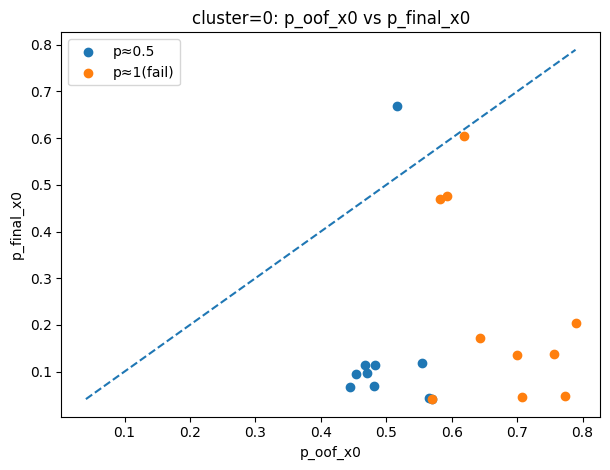

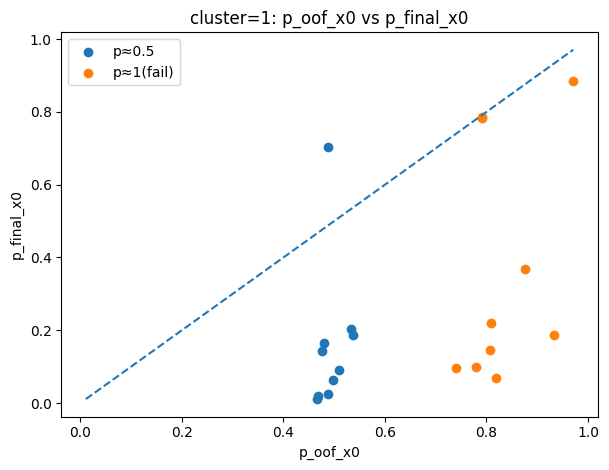

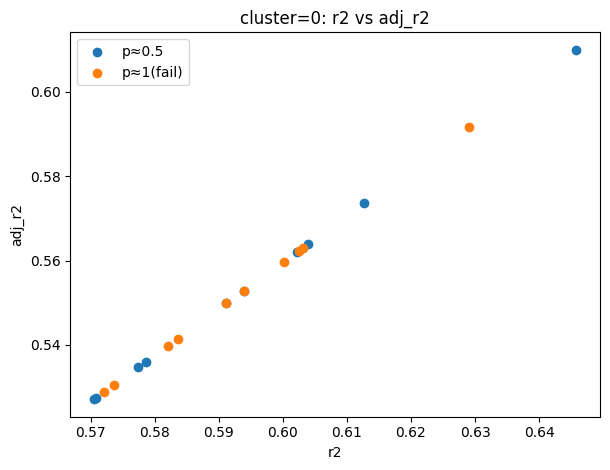

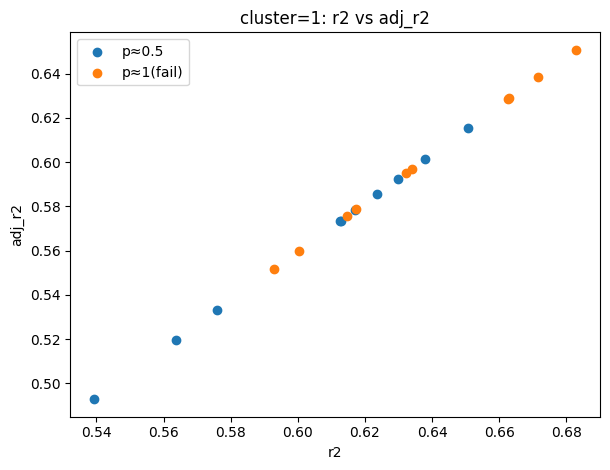

In [11]:
# df_metrics 已存在
df = df_metrics.copy()
df["group_label"] = df["group"].astype(str)

# ========= 圖 1：p_oof_x0 (x) vs p_final_x0 (y)，cluster 分圖、group 分色 =========
clusters = sorted(df["cluster"].unique())

for c in clusters:
    sub = df[df["cluster"] == c].copy()
    groups = list(sub["group_label"].unique())

    plt.figure(figsize=(6.2, 4.8))

    for g in groups:
        s = sub[sub["group_label"] == g]
        plt.scatter(s["p_oof_x0"], s["p_final_x0"], label=g)

    # 參考線 y=x（用該 cluster 內的範圍）
    mn = min(sub["p_oof_x0"].min(), sub["p_final_x0"].min())
    mx = max(sub["p_oof_x0"].max(), sub["p_final_x0"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")

    plt.xlabel("p_oof_x0")
    plt.ylabel("p_final_x0")
    plt.title(f"cluster={c}: p_oof_x0 vs p_final_x0")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ========= 圖 2：r2 (x) vs adj_r2 (y)，cluster 分圖、group 分色 =========
for c in clusters:
    sub = df[df["cluster"] == c].copy()
    groups = list(sub["group_label"].unique())

    plt.figure(figsize=(6.2, 4.8))

    for g in groups:
        s = sub[sub["group_label"] == g]
        plt.scatter(s["r2"], s["adj_r2"], label=g)

    plt.xlabel("r2")
    plt.ylabel("adj_r2")
    plt.title(f"cluster={c}: r2 vs adj_r2")
    plt.legend()
    plt.tight_layout()
    plt.show()


---
---

In [26]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y
# ========= 1) 把 OOF function 改成可切換 smote =========
def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42, do_smote=True):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            if do_smote:
                sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
                X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

# 1) 兩個專家的 OOF（同一個 X_all_df / c_all）
p_oof_A = oof_proba_per_cluster(X_all_df, y_real, c_all, do_smote=True)   # 有重抽
p_oof_B = oof_proba_per_cluster(X_all_df, y_real, c_all, do_smote=False)  # 無重抽
diff_oof = p_oof_A - p_oof_B

# ========= 2) 把 final fit function 改成可切換 smote =========
def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42, do_smote=True):
    models = {}
    y_all = np.asarray(y_all).astype(int)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        if do_smote:
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            Xc, yc = sm.fit_resample(Xc, yc)

        m = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=10,
            gamma=1.0,
            reg_lambda=2.0,
            reg_alpha=0.5,
            random_state=random_state,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
        )
        models[c] = m.fit(Xc, yc)

    return models

# 2) 兩個專家的 final model（用於 lattice/surrogate）
blackbox_A = fit_blackbox_per_cluster(X_all_df, y_real, c_all, do_smote=True)
blackbox_B = fit_blackbox_per_cluster(X_all_df, y_real, c_all, do_smote=False)

# ========= 3) 差異 blackbox wrapper：不改 local_surrogate_lattice_cube_linear =========
class TwoExpertProbDiff:
    """
    把兩個模型的機率差 g(x)=pA(x)-pB(x) 映射到 [0,1]：
        z(x) = 0.5*(g(x)+1)
    讓 local_surrogate_lattice_cube_linear 可以照舊用 predict_proba()[:,1] 取 z(x)

    若要回到原始差異尺度：
        g(x) = 2*z(x) - 1
    係數也跟著乘 2（截距做 2*b0 - 1）。
    """
    def __init__(self, model_A, model_B):
        self.A = model_A
        self.B = model_B

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        pA = self.A.predict_proba(X)[:, 1]
        pB = self.B.predict_proba(X)[:, 1]
        g  = pA - pB                      # [-1, 1]
        z  = 0.5 * (g + 1.0)              # [0, 1]
        z  = np.clip(z, 0.0, 1.0)
        return np.column_stack([1.0 - z, z])

    def raw_diff(self, X):
        X = np.asarray(X, dtype=float)
        return self.A.predict_proba(X)[:, 1] - self.B.predict_proba(X)[:, 1]

# 3) 每群建立差異 blackbox（predict_proba 回傳的是映射後的 z）
diff_blackbox_by_c = {c: TwoExpertProbDiff(blackbox_A[c], blackbox_B[c]) for c in [0, 1]}

# ========= 4) 依 |Δ| 挑 x0（在各群內） =========
def pick_x0_by_absdiff(diff, topk=10):
    diff = np.asarray(diff).reshape(-1)
    idx = np.arange(len(diff))
    order = np.argsort(-np.abs(diff))    # 由大到小
    return idx[order[:min(topk, idx.size)]]


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ========= 5) per-cluster local surrogate：blackbox 改成「差異模型」 =========
def run_local_surrogates_diff_per_cluster(
    X_all_df, c_all,
    diff_blackbox_by_c,
    diff_oof,                 # 在真實點上的 OOF 差異：pA_oof - pB_oof
    n_samples=500, delta=0.1, topk=10, random_state=42
):
    all_infos = []

    for c in sorted(diff_blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        diff_c = np.asarray(diff_oof)[idx_c]
        loc = pick_x0_by_absdiff(diff_c, topk=topk)

        m_diff = diff_blackbox_by_c[c]

        for j, pos in enumerate(loc):
            global_idx = int(idx_c[pos])
            x0 = X_all_df.iloc[global_idx].to_numpy()

            g, info = local_surrogate_lattice_cube_linear(
                x0=x0,
                blackbox_model=m_diff,     # 這裡換成差異 blackbox
                n_samples=n_samples,
                delta=delta,
                max_full_grid=200_000,
                k=10,
                random_state=random_state,
                scaler=None,              # 已在標準化空間
            )

            # 記錄差異相關欄位
            info["cluster"]    = int(c)
            info["group"]      = "|Δ| top"
            info["i"]          = int(j)
            info["x0_index"]   = global_idx
            info["diff_oof_x0"] = float(diff_c[pos])  # pA_oof - pB_oof（原始尺度）

            # final 差異（原始尺度）
            info["diff_final_x0"] = float(m_diff.raw_diff(x0.reshape(1, -1))[0])

            info["feature_names"] = list(X_all_df.columns)

            # surrogate 目標是 z=0.5*(diff+1)，把係數轉回 diff 尺度（線性縮放）
            # diff_hat(x) = 2*z_hat(x) - 1
            if "coef" in info and info["coef"] is not None:
                info["coef_diff_scale"] = (2.0 * np.asarray(info["coef"], dtype=float)).tolist()
            if "intercept" in info and info["intercept"] is not None:
                info["intercept_diff_scale"] = float(2.0 * info["intercept"] - 1.0)

            all_infos.append(info)

    return all_infos

# 4) 在 |Δ| 最大的點做 local surrogate（解釋「差異」）
infos_all = run_local_surrogates_diff_per_cluster(
    X_all_df=X_all_df,
    c_all=c_all,
    diff_blackbox_by_c=diff_blackbox_by_c,
    diff_oof=diff_oof,
    n_samples=1000,
    delta=0.1,
    topk=10,
    random_state=42
)

# ========= 6) metrics 表：補上兩專家與差異 =========
def infos_to_metrics_df(infos):
    rows = []
    for d in infos:
        rows.append({
            "cluster": d.get("cluster", None),
            "group": d.get("group", None),
            "i": d.get("i", None),
            "x0_index": d.get("x0_index", None),

            "diff_oof_x0": d.get("diff_oof_x0", np.nan),
            "diff_final_x0": d.get("diff_final_x0", np.nan),

            "r2": d.get("r2", np.nan),
            "adj_r2": d.get("adj_r2", np.nan),
            "aic": d.get("aic", np.nan),
            "bic": d.get("bic", np.nan),
            "mse": d.get("mse", np.nan),
            "k": d.get("k", None),
            "delta": d.get("delta", None),
            "mode": d.get("mode", None),
        })
    return pd.DataFrame(rows).sort_values(["cluster", "group", "i"]).reset_index(drop=True)

df_metrics = infos_to_metrics_df(infos_all)
df_metrics

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_24060\3358342355.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,cluster,group,i,x0_index,diff_oof_x0,diff_final_x0,r2,adj_r2,aic,bic,mse,k,delta,mode
0,0,|Δ| top,0,1132,0.751762,-0.045846,0.625801,0.307731,-4615.635823,-2358.068394,0.003944,10,0.1,sampled_grid
1,0,|Δ| top,1,807,0.734271,0.102349,0.674914,0.398591,-4773.008010,-2515.440582,0.003369,10,0.1,sampled_grid
2,0,|Δ| top,2,1054,0.717722,0.114530,0.665021,0.380290,-4738.288565,-2480.721137,0.003488,10,0.1,sampled_grid
3,0,|Δ| top,3,983,0.669020,0.045382,0.635853,0.326328,-5349.275854,-3091.708426,0.001894,10,0.1,sampled_grid
4,0,|Δ| top,4,1099,0.660979,-0.029112,0.643489,0.340454,-5133.936201,-2876.368772,0.002349,10,0.1,sampled_grid
5,0,|Δ| top,5,1093,0.605558,-0.028271,0.637900,0.330116,-4856.741087,-2599.173659,0.003099,10,0.1,sampled_grid
6,0,|Δ| top,6,461,0.579398,0.377083,0.663230,0.376975,-4533.779783,-2276.212355,0.004280,10,0.1,sampled_grid
7,0,|Δ| top,7,1216,0.554277,0.491171,0.697532,0.440434,-4882.946765,-2625.379337,0.003019,10,0.1,sampled_grid
8,0,|Δ| top,8,1287,0.545549,0.509268,0.664759,0.379804,-4582.803324,-2325.235896,0.004075,10,0.1,sampled_grid
9,0,|Δ| top,9,1215,0.532685,0.038967,0.636544,0.327607,-5041.399483,-2783.832054,0.002576,10,0.1,sampled_grid
